##*ADEOTI Nihimath*
##Cours: LLM

*Projet: Système de RAG sur la documentation web de MDN en français et comparer:
- **closed-book** (le LLM seul) vs **RAG** (LLM + récupération) ;
- l'effet du nombre de passages **k** ;
- un retrieveur **de base** vs **spécialisé** (fine-tuné).



## 0. Commençons par s'assurer de travailler avec le GPU

In [1]:
!nvidia-smi

Sun Jun  7 23:02:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             37W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

La commande ayant fonctionné, on est bien sur le GPU T4.

## 1. Récupérer le code et installer les dépendances
Remplacez l'URL par celle de **votre** dépôt après l'avoir poussé sur GitHub.

In [2]:
!git clone https://github.com/nihmad/systeme-rag.git
%cd systeme-rag
!pip install -q -r requirements.txt

fatal: destination path 'systeme-rag' already exists and is not an empty directory.
/content/systeme-rag


## 2. Construire le corpus (clone partiel de MDN + nettoyage + découpage)

In [4]:
import gc, torch

# supprime toutes les variables qui pointent vers un modèle
for name in ["model", "generator", "gen", "llm", "pipe"]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()

print(f"VRAM libre : {torch.cuda.mem_get_info()[0]/1e9:.1f} Go")

VRAM libre : 15.5 Go


In [5]:
!python scripts/01_build_corpus.py

[corpus] Clone partiel de MDN (cela peut prendre 1-2 min)…
  $ git clone --depth 1 --filter=blob:none --sparse https://github.com/mdn/translated-content.git /content/systeme-rag/data/mdn_clone
Cloning into '/content/systeme-rag/data/mdn_clone'...
remote: Enumerating objects: 37482, done.
remote: Counting objects: 100% (37482/37482), done.
remote: Compressing objects: 100% (4056/4056), done.
remote: Total 37482 (delta 8), reused 36215 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (37482/37482), 2.78 MiB | 7.48 MiB/s, done.
Resolving deltas: 100% (8/8), done.
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 21 (delta 0), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 37.41 KiB | 3.40 MiB/s, done.
  $ git sparse-checkout set files/fr/web/html files/fr/web/css files/fr/web/javascript/guide
remote: Enumerating objects: 1488, done.
remote: Counting obje

Aperçu de quelques passages :

In [6]:
import json
chunks = [json.loads(l) for l in open('data/chunks.jsonl', encoding='utf-8')]
print('Nombre de passages :', len(chunks))
print(chunks[0]['title'])
print(chunks[0]['text'][:300], '…')

Nombre de passages : 8943
Utiliser les requêtes de conteneurs ancrés
Le positionnement par ancre CSS inclut des mécanismes pour fournir des options de repli. Ce sont des positions alternatives que le navigateur peut essayer de placer pour un élément positionné par ancre, par rapport à son ancre, afin de le remettre à l'écran si l'élément positionné commence à déborde …


## 3. Indexer les passages (embeddings + FAISS)

In [7]:
!python scripts/02_build_index.py

[retriever] Chargement de l'embedding model : intfloat/multilingual-e5-base
Loading weights: 100% 199/199 [00:00<00:00, 3974.41it/s]
Batches: 100% 280/280 [02:04<00:00,  2.25it/s]
[retriever] Index construit : 8943 vecteurs, dim=768
[retriever] Index sauvegardé dans /content/systeme-rag/data/faiss_index


## 4. Générer le jeu d'évaluation
On crée des paires (question, réponse, passage source) à partir du corpus.
*La génération est lente : commencez avec un petit `-n` pour tester.*
Le fichier produit (`data/eval_set.jsonl`) est ensuite versionné dans le dépôt :
c'est lui qui rend vos résultats reproductibles.

In [10]:
!python scripts/03_make_eval_set.py -n 10

[generator] Chargement du LLM : unsloth/mistral-7b-instruct-v0.3 (4bit=True)
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 291/291 [01:02<00:00,  4.68it/s]
[transformers] Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Bo

In [11]:
import json
exemples = [json.loads(l) for l in open('data/eval_set.jsonl', encoding='utf-8')]
for r in exemples[:3]:
    print("Q :", r['question'])
    print("R :", r['answer'])
    print("source :", r['gold_chunk_id'])

Q : Qu'est-ce qui se passe avec le canal alpha lorsque le canal alpha de la couleur de sortie n'est pas défini ?
R : Il prend par défaut la même valeur que le canal alpha de la couleur d'origine.
source : Web/CSS/Reference/Values/color_value/hwb::12
Q : Quel attribut permet de définir l'URL préférée pour le document actuel, ce qui aide les moteurs de recherche à réduire le contenu dupliqué ?
R : L'attribut `canonical`
source : Web/HTML/Reference/Attributes/rel::14
Q : Quel est l'ordre de priorité des déclarations CSS en présence de plusieurs couches ?
R : La première couche déclarée a la priorité la plus faible et la dernière la plus forte.
source : Web/CSS/Reference/At-rules/@layer::2


In [12]:
!python scripts/03_make_eval_set.py -n 100

[generator] Chargement du LLM : unsloth/mistral-7b-instruct-v0.3 (4bit=True)
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 291/291 [01:04<00:00,  4.51it/s]
[transformers] Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Bo

## 5. Évaluation : RAG vs closed-book + ablation sur k
Produit `results/report_base.json`.

In [21]:
%cd /content/systeme-rag
!python scripts/04_run_evaluation.py --n_gen 30

/content/systeme-rag
[eval] 100 exemples — index = base
[retriever] Chargement de l'embedding model : intfloat/multilingual-e5-base
Loading weights: 100% 199/199 [00:00<00:00, 5868.80it/s]
[retriever] Index chargé : 8943 vecteurs

RÉCUPÉRATION
{
  "hit@1": 0.56,
  "hit@3": 0.82,
  "hit@5": 0.86,
  "hit@10": 0.92,
  "mrr": 0.6957
}
[generator] Chargement du LLM : unsloth/mistral-7b-instruct-v0.3 (4bit=True)
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 291/291 [01:02<00:00,  4.65it/s]
[transformers] Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i 

## 6. Spécialiser le retrieveur, puis comparer
On fine-tune l'embedding model sur le domaine, on réindexe, et on réévalue
pour mesurer le gain de la spécialisation.

In [22]:
!python scripts/05_finetune_embedder.py --epochs 2
!python scripts/02_build_index.py --finetuned
!python scripts/04_run_evaluation.py --finetuned --n_gen 30

[finetune] 70 paires d'entraînement, 30 en test
Loading weights: 100% 199/199 [00:00<00:00, 6007.00it/s]
{'train_runtime': '8.973', 'train_samples_per_second': '15.6', 'train_steps_per_second': '1.114', 'train_loss': '0.8699', 'epoch': '2'}
100% 10/10 [00:08<00:00,  1.11it/s]
Writing model shards: 100% 1/1 [00:12<00:00, 12.42s/it]
[finetune] Modèle spécialisé sauvegardé -> /content/systeme-rag/data/embedder_finetuned
[retriever] Chargement de l'embedding model : /content/systeme-rag/data/embedder_finetuned
Loading weights: 100% 199/199 [00:00<00:00, 4585.50it/s]
Batches: 100% 280/280 [02:09<00:00,  2.16it/s]
[retriever] Index construit : 8943 vecteurs, dim=768
[retriever] Index sauvegardé dans /content/systeme-rag/data/faiss_index_finetuned
[eval] 100 exemples — index = finetuned
[retriever] Chargement de l'embedding model : /content/systeme-rag/data/embedder_finetuned
Loading weights: 100% 199/199 [00:00<00:00, 22627.66it/s]
[retriever] Index chargé : 8943 vecteurs

RÉCUPÉRATION
{
  "

## 7. Comparer les rapports
Tableau récapitulatif base vs spécialisé.

In [23]:
import json, pandas as pd
rows = []
for tag in ['base', 'finetuned']:
    try:
        r = json.load(open(f'results/report_{tag}.json', encoding='utf-8'))
    except FileNotFoundError:
        continue
    d = {'index': tag, **r['retrieval']}
    if 'generation' in r:
        d['F1_RAG'] = r['generation']['rag']['F1']
        d['F1_closed_book'] = r['generation']['closed_book']['F1']
    rows.append(d)
pd.DataFrame(rows)

,index,hit@1,hit@3,hit@5,hit@10,mrr,F1_RAG,F1_closed_book
0,base,0.56,0.82,0.86,0.92,0.6957,0.3046,0.1489
1,finetuned,0.63,0.88,0.92,0.95,0.7583,0.3228,0.1341


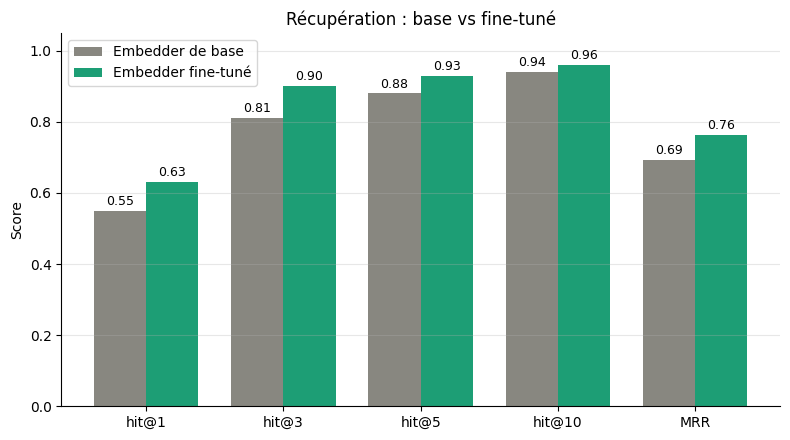

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("results", exist_ok=True)

# Données issues de tes rapports d'évaluation
metriques = ["hit@1", "hit@3", "hit@5", "hit@10", "MRR"]
base      = [0.55, 0.81, 0.88, 0.94, 0.6923]
finetuned = [0.63, 0.90, 0.93, 0.96, 0.7636]

x = np.arange(len(metriques))
largeur = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - largeur/2, base,      largeur, label="Embedder de base",   color="#888780")
b2 = ax.bar(x + largeur/2, finetuned, largeur, label="Embedder fine-tuné", color="#1D9E75")

for barres in (b1, b2):
    ax.bar_label(barres, fmt="%.2f", padding=2, fontsize=9)

ax.set_ylabel("Score")
ax.set_title("Récupération : base vs fine-tuné")
ax.set_xticks(x, metriques)
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/retrieval_base_vs_finetuned.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
import sys; sys.path.insert(0, '.')
from ragdoc.retriever import Retriever
from ragdoc.generator import Generator
from ragdoc.pipeline import RagPipeline

retriever = Retriever.load()
generator = Generator()
rag = RagPipeline(retriever, generator)

out = rag.answer("À quoi sert l'élément HTML <article> ?")
print("RÉPONSE :", out['answer'])
print("\nSOURCES :")
for s in out['sources']:
    print(' -', s['title'], '|', round(s['score'], 3))

[retriever] Chargement de l'embedding model : intfloat/multilingual-e5-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[retriever] Index chargé : 8943 vecteurs
[generator] Chargement du LLM : unsloth/mistral-7b-instruct-v0.3 (4bit=True)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


RÉPONSE : L'élément HTML `<article>` sert à représenter une composition autonome dans un document, une page, une application ou un site, destinée à être distribuée ou réutilisée indépendamment. Cela peut inclure des messages de forum, des articles de magazine ou de journal, des entrées de blog, des commentaires soumis par un utilisateur, des widgets ou gadgets interactifs, ou tout autre élément de contenu indépendant. Il est utilisé pour regrouper le contenu afin qu'il puisse être facilement stylé à l'aide des attributs class ou id, pour marquer une section d'un document comme étant écrite dans une langue différente (à l'aide de l'attribut lang), etc. Il ne représente rien en soi et doit uniquement être utilisé lorsque aucun autre élément sémantique n'est approprié.

SOURCES :
 - Élément HTML `<article>` : l'élément de contenu d'un article | 0.898
 - Élément HTML `<div>` : l'élément de division du contenu | 0.887
 - Élément HTML `<search>` : l'élément de recherche | 0.883
 - Élément HT

## 8. Analyse et conclusions



Sur la récupération, le fine-tuning de l'embedder gagne sur toute la ligne, avec les gains les plus nets en haut du classement : hit@1 passe de 0.55 à 0.63 (+8 points) et hit@3 de 0.81 à 0.90 (+9 points), tandis que le MRR grimpe de 0.69 à 0.76. C'est exactement le comportement recherché : le modèle spécialisé place le bon document plus souvent en première position ou tout en haut. Les gains se resserrent à hit@10 (0.94 → 0.96) à cause d'un effet plafond : retrouver le bon document dans le top-10 était déjà presque systématique, il restait peu de marge.
Sur la génération, le résultat central c'est l'écart entre RAG et closed-book. En base, le F1 passe de 0.144 (closed-book) à 0.312 (RAG), soit plus du double.**Autrement dit, donner le contexte récupéré au LLM améliore drastiquement la qualité des réponses par rapport à sa seule mémoire paramétrique.**

**Le retrieval n'est pas décoratif, il porte la performance.**
Le fine-tuning du retriever se répercute aussi sur la génération end-to-end, mais plus modestement : F1 0.312 → 0.325, ROUGE-L 0.296 → 0.303, et l'EM décolle légèrement de 0 à 0.033.  Un meilleur retrieval donne un meilleur contexte, donc de meilleures réponses, mais le gain est amorti parce qu'aux rangs effectivement utilisés (top-k) les deux retrievers ramènent déjà souvent le bon document donc l'amélioration ne joue que sur les cas limites.

L'EM est quasi nul partout. C'est normal et attendu. L'Exact Match exige que la réponse générée corresponde mot pour mot à la référence, or un LLM génératif comme Mistral produit des phrases complètes et reformulées, pas des spans exacts. Pour de la génération libre, l'EM est donc une métrique peu adaptée. Ce sont le F1 (recouvrement de tokens) et le ROUGE-L qui sont pertinents ici.
Une évaluation sémantique (BERTScore, ou un LLM-as-judge) capturerait mieux la qualité réelle des réponses.
En résumé : RAG double le F1 face au closed-book (la valeur ajoutée de la récupération) ; la spécialisation de l'embedder améliore surtout le retrieval (hit@1 +8 pts, MRR +7 pts) et, par ricochet, légèrement la génération ; et l'EML est inadapté à la génération libre, d'où l'intérêt de métriques de recouvrement et, en perspective, d'une évaluation sémantique.

In [18]:
!pip install gradio -q

import gradio as gr

def repondre(question):
    if not question or not question.strip():
        return "Pose une question.", ""
    out = rag.answer(question)
    reponse = out["answer"]
    sources = "**Sources récupérées :**\n" + "\n".join(
        f"- {s['title']}  *(score : {round(s['score'], 3)})*"
        for s in out["sources"]
    )
    return reponse, sources

with gr.Blocks(title="Système RAG") as demo:
    gr.Markdown(
        "# Démonstrateur RAG\n"
        "Pose une question : le système récupère les documents pertinents "
        "puis génère une réponse avec Mistral-7B."
    )
    question = gr.Textbox(
        label="Ta question",
        placeholder="Ex. : À quoi sert l'élément HTML <article> ?",
    )
    btn = gr.Button("Interroger", variant="primary")
    reponse = gr.Textbox(label="Réponse générée", lines=6)
    sources = gr.Markdown()

    btn.click(repondre, inputs=question, outputs=[reponse, sources])
    question.submit(repondre, inputs=question, outputs=[reponse, sources])

    gr.Examples(
        examples=[
            "À quoi sert l'élément HTML <article> ?",
            "Quelle est la différence entre <div> et <span> ?",
            "Comment fonctionne l'attribut alt d'une image ?",
        ],
        inputs=question,
    )

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cece591d7c85f05e86.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
